# 📅 Week 3 — Feature Engineering & Target Creation

**SOC · Stock Trend Predictor **

> *Week 2 ended with clean data and a solid understanding of how stock prices move. Week 3 turns that understanding into something a machine learning model can actually learn from.*

## What We're Doing This Week

| Section | Topic |
| --- | --- |
| **1** | What is feature engineering? |
| **2** | Loading your cleaned data |
| **3** | Building 8 features step by step |
| **4** | Creating the Target column (Up/Down) |
| **5** | Data leakage — the #1 beginner mistake |
| **6** | Final check and saving the ML-ready dataset |
| **7** | Week 3 Assignment |

No model building yet. This week is about giving your model the right ingredients. A well-built dataset is 80% of the work.


## Learning Objectives

By the end of this week, you will be able to:

- Explain what a feature is and why raw stock prices aren't enough
- Build 8 meaningful features from scratch using pandas
- Create a Target column that labels each day as Up (1) or Down (0)
- Explain data leakage and how to avoid it
- Save a clean, ML-ready CSV file



## 1 · What Is Feature Engineering?

### The Problem with Raw Data

Imagine you hand a model this table and ask it to predict tomorrow:

| Date | Open | High | Low | Close | Volume |
| --- | --- | --- | --- | --- | --- |
| 2024-01-10 | 185.2 | 187.4 | 184.1 | 186.8 | 52M |
| 2024-01-11 | 186.8 | 188.0 | 185.5 | 187.3 | 41M |

The model sees numbers. But it doesn't automatically know:
- Is the price trending up or down over the past week?
- Is today's move big or small compared to recent history?
- Did high volume confirm the move?

These are facts. But a machine learning model doesn't learn from facts alone — it learns from **patterns**.

**Feature engineering is the process of creating new columns that answer these questions.** You're translating your domain knowledge (what you know about stocks) into numbers the model can use.

### A Simple Analogy

> Imagine you're trying to predict tomorrow's weather. The raw data is: temperature = 28°C.
> That's not very useful alone. But if you also know: 'temperature has risen 5°C over the last 3 days' and 'humidity has spiked today' — suddenly you have signals to work with.
> That's exactly what we're doing with stock data.


### What We Already Have from Week 2

You calculated a few columns during EDA. Let's review:

| Column | Already created? |
| --- | --- |
| `Daily_Return` | ✅ Yes — in Section 3.5 |
| `MA20` | ✅ Yes — in Section 3.4 |
| `MA50` | ✅ Yes — in Section 3.4 |
| `Daily_Range` | ✅ Yes — in Section 1.3 |
| `OC_Change` | ✅ Yes — in Section 1.3 |

This week we build on those and add 3 more to complete our 8-feature set.


## 2 · Load Your Cleaned Data

We start from the CSV you saved at the end of Week 2. This is why saving matters — you don't have to re-download and re-clean every time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the cleaned file from Week 2
df = pd.read_csv("data/processed/AAPL_clean.csv", index_col="Date", parse_dates=True)


> 💡 **If you don't have the CSV yet**, run the Week 2 setup cell first to download, clean, and save the data.


### 2.1 — Rebuild Week 2 Columns

Some of the columns we made during Week 2 EDA won't be in your saved CSV. Let's rebuild the ones we need as our starting point.

In [2]:
# Rebuild the columns from Week 2 that we'll build on this week

# How much did price move intraday? (High - Low)
df["Daily_Range"] = df["High"] - df["Low"]

# % change from Open to Close each day
df["OC_Change"] = (df["Close"] - df["Open"]) / df["Open"] * 100

# % change in Close from one day to the next
df["Daily_Return"] = df["Close"].pct_change()

# 20-day and 50-day moving averages (from Week 2 visualization)
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()
print(df[["Close", "Daily_Range", "OC_Change", "Daily_Return", "MA20", "MA50"]].tail())

                 Close  Daily_Range  OC_Change  Daily_Return        MA20  \
Date                                                                       
2026-05-18  297.839996     5.750000  -0.799359     -0.007961  282.607747   
2026-05-19  298.970001     4.160004   0.673469      0.003794  284.259996   
2026-05-20  302.250000     4.720001   1.364950      0.010971  285.726567   
2026-05-21  304.989990     5.140015   1.305385      0.009065  287.317151   
2026-05-22  308.820007     5.559998   0.882011      0.012558  289.217627   

                  MA50  
Date                    
2026-05-18  266.783852  
2026-05-19  267.570436  
2026-05-20  268.403638  
2026-05-21  269.292040  
2026-05-22  270.357949  



## 3 · Building Features Step by Step

We're building exactly 8 features. For each one, I'll tell you:
- **What it is** in plain English
- **Why it might help** the model
- **How to build it** in code

Here's the full list before we start:

| # | Feature | What it captures |
| --- | --- | --- |
| 1 | `MA5` | Very short-term trend |
| 2 | `MA5_to_MA20` | Is the short trend above the long trend? |
| 3 | `Price_to_MA20` | Is today's price above its recent average? |
| 4 | `Daily_Return` | Did the price go up or down today? (already built) |
| 5 | `Lag1_Return` | What did the price do yesterday? |
| 6 | `Lag2_Return` | What did the price do two days ago? |
| 7 | `Volatility_5d` | How turbulent has the market been recently? |
| 8 | `Volume_Change` | Is today's volume unusual? |

Let's build them one by one.


### Feature 1 — MA5 (5-Day Moving Average)

**What it is:** The average closing price over the last 5 trading days (one week).

**Why it helps:** If price is consistently above its 5-day average, that's a short-term uptrend. The model can use this to understand recent momentum.

> You already know MA20 and MA50 from Week 2. MA5 captures an even shorter window — just one week of trading.

In [3]:
# 5-day moving average — average of the last 5 closing prices
df["MA5"] = df["Close"].rolling(window=5).mean()

# Quick look at the three moving averages side by side
print(df[["Close", "MA5", "MA20", "MA50"]].dropna().tail(10))

                 Close         MA5        MA20        MA50
Date                                                      
2026-05-11  292.679993  288.813843  274.645944  263.135558
2026-05-12  294.799988  290.990155  276.456357  263.742032
2026-05-13  298.869995  293.315082  278.090619  264.449287
2026-05-14  298.209991  295.521997  279.843242  265.167920
2026-05-15  300.230011  296.957996  281.355679  265.971512
2026-05-18  297.839996  297.989996  282.607747  266.783852
2026-05-19  298.970001  298.823999  284.259996  267.570436
2026-05-20  302.250000  299.500000  285.726567  268.403638
2026-05-21  304.989990  300.856000  287.317151  269.292040
2026-05-22  308.820007  302.573999  289.217627  270.357949


> 💡 **Why do the first few rows show NaN?** A 5-day moving average needs 5 days of data before it can calculate anything. Those first 4 rows will always be NaN — that's expected.

### Feature 2 — MA5_to_MA20 (Short Trend vs Long Trend)

**What it is:** The ratio of the 5-day average to the 20-day average. (The short-term average divided by the long-term average.)

**Why it helps:** Instead of giving the model two separate MA columns, this single ratio captures the *relationship* between them — which is the signal traders actually use.



> You might have heard of the "Golden Cross" (short MA crosses above long MA) and "Death Cross" (short MA crosses below long MA). This ratio captures exactly that concept.

In [4]:
# Ratio of 5-day to 20-day moving average

# Values > 1 → short-term trend above long-term (bullish)
# Values < 1 → short-term trend below long-term (bearish)
df["MA5_to_MA20"] = df["MA5"] / df["MA20"]

print(df[["MA5", "MA20", "MA5_to_MA20"]].dropna().tail(10))
print()
print(f"Average ratio: {df['MA5_to_MA20'].mean():.4f}")
print(f"Min ratio: {df['MA5_to_MA20'].min():.4f}")
print(f"Max ratio: {df['MA5_to_MA20'].max():.4f}")

                   MA5        MA20  MA5_to_MA20
Date                                           
2026-05-11  288.813843  274.645944     1.051586
2026-05-12  290.990155  276.456357     1.052572
2026-05-13  293.315082  278.090619     1.054746
2026-05-14  295.521997  279.843242     1.056027
2026-05-15  296.957996  281.355679     1.055454
2026-05-18  297.989996  282.607747     1.054430
2026-05-19  298.823999  284.259996     1.051235
2026-05-20  299.500000  285.726567     1.048205
2026-05-21  300.856000  287.317151     1.047122
2026-05-22  302.573999  289.217627     1.046181

Average ratio: 1.0061
Min ratio: 0.8873
Max ratio: 1.0686


---

### Feature 3 — Price_to_MA20 (Price vs Its Recent Average)

**What it is:** How far today's closing price is from the 20-day average, expressed as a ratio.

**Why it helps:** 
- A value **above 1.0** means the stock is trading *above* its recent average → possible bullish momentum
- A value **below 1.0** means the stock is trading *below* its recent average → possible bearish pressure

This is much more informative than raw Close because it tells the model *where* price sits relative to recent history.


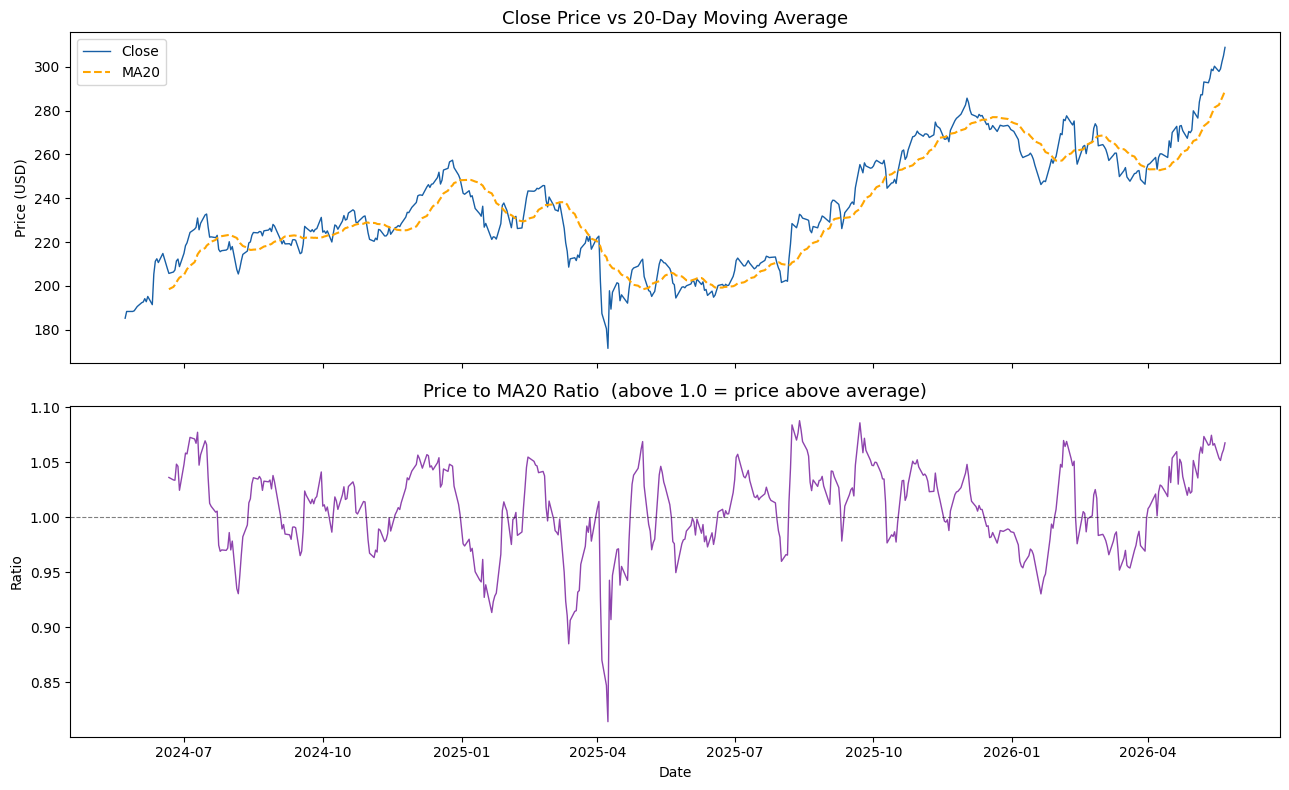

In [5]:
# Is today's price above or below its 20-day average?
df["Price_to_MA20"] = df["Close"] / df["MA20"]

# Let's visualize this to make it intuitive
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df.index, df["Close"], label="Close", linewidth=1, color="#185FA5")
axes[0].plot(df.index, df["MA20"], label="MA20", linewidth=1.5, color="orange", linestyle="--")
axes[0].set_title("Close Price vs 20-Day Moving Average", fontsize=13)
axes[0].legend()
axes[0].set_ylabel("Price (USD)")

axes[1].plot(df.index, df["Price_to_MA20"], linewidth=1, color="#8E44AD")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[1].set_title("Price to MA20 Ratio  (above 1.0 = price above average)", fontsize=13)
axes[1].set_ylabel("Ratio")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


💡 Observation: The ratio oscillates around 1.0. Periods above 1.0 correspond to stronger-than-average prices, while periods below 1.0 correspond to weaker-than-average prices.

### Feature 4 — Daily_Return (Already Built)

You built this in Week 2 using `pct_change()`. We're keeping it as-is.

**What it is:** `(Close_today - Close_yesterday) / Close_yesterday`

**Why it helps:** Percentage returns are stationary — they don't trend upward over time the way raw prices do. This makes them much better inputs for ML models.

Let's just confirm it's still in our DataFrame:

In [6]:
# Confirm Daily_Return exists from our rebuild step
print("Daily_Return exists:", "Daily_Return" in df.columns)
print(df["Daily_Return"].describe().round(4))

Daily_Return exists: True
count    500.0000
mean       0.0012
std        0.0178
min       -0.0925
25%       -0.0065
50%        0.0015
75%        0.0091
max        0.1533
Name: Daily_Return, dtype: float64


---

### Feature 5 — Lag1_Return (Yesterday's Return)

**What it is:** The daily return from *yesterday*, shifted forward by one row.

**Why it helps:** If yesterday was a big down day, does the market tend to bounce? Or does it continue falling? This gives the model a one-day memory.

> **"Lag"** is a time series term meaning "shifted back in time." Lag 1 = one day ago.

In [7]:
# Shift Daily_Return by 1 row — today's Lag1_Return is yesterday's Daily_Return
df["Lag1_Return"] = df["Daily_Return"].shift(1)
# we do shift(1) here note if we do shift(-1) may lead to data leakage 
# Verify: Lag1_Return on row N should equal Daily_Return on row N-1
print(df[["Daily_Return", "Lag1_Return"]].dropna().head(8))

            Daily_Return  Lag1_Return
Date                                 
2024-05-28      0.000053     0.016588
2024-05-29      0.001579     0.000053
2024-05-30      0.005255     0.001579
2024-05-31      0.005019     0.005255
2024-06-03      0.009259     0.005019
2024-06-04      0.001649     0.009259
2024-06-05      0.007821     0.001649
2024-06-06     -0.007097     0.007821


> 💡 **Why does the first row have NaN?** Because there's no "yesterday" for the very first row. `shift(1)` always creates one NaN at the top. This is expected.

---

### Feature 6 — Lag2_Return (Two Days Ago)

Same idea, but looking back two days. Some market patterns play out over two days rather than one.

In [8]:
# Shift by 2 rows — today's Lag2_Return is two days ago's Daily_Return
df["Lag2_Return"] = df["Daily_Return"].shift(2)

print(df[["Daily_Return", "Lag1_Return", "Lag2_Return"]].dropna().head(8))

            Daily_Return  Lag1_Return  Lag2_Return
Date                                              
2024-05-29      0.001579     0.000053     0.016588
2024-05-30      0.005255     0.001579     0.000053
2024-05-31      0.005019     0.005255     0.001579
2024-06-03      0.009259     0.005019     0.005255
2024-06-04      0.001649     0.009259     0.005019
2024-06-05      0.007821     0.001649     0.009259
2024-06-06     -0.007097     0.007821     0.001649
2024-06-07      0.012392    -0.007097     0.007821


---

### Feature 7 — Volatility_5d (5-Day Rolling Volatility)

**What it is:** The standard deviation of daily returns over the last 5 days.

**Why it helps:** High volatility = the market is uncertain. Low volatility = calm trending. A model might behave differently in volatile periods vs calm ones. This feature captures that context.

> Standard deviation measures how spread out the values are. A large std means the returns were all over the place. A small std means they were close together.

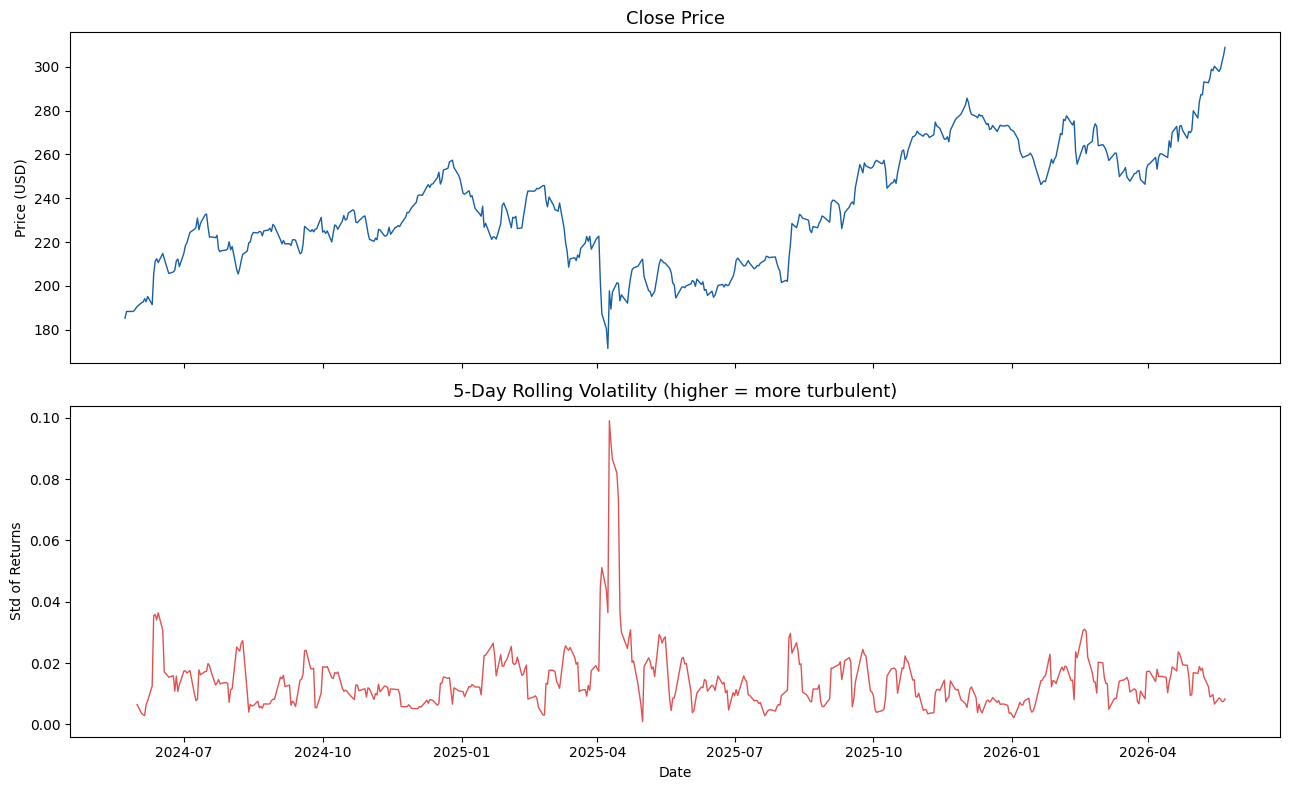

In [ ]:
# Standard deviation of daily returns over last 5 days
df["Volatility_5d"] = df["Daily_Return"].rolling(window=5).std()

# Visualize: compare volatility to price
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df.index, df["Close"], linewidth=1, color="#185FA5")
axes[0].set_title("Close Price", fontsize=13)
axes[0].set_ylabel("Price (USD)")

axes[1].plot(df.index, df["Volatility_5d"], linewidth=1, color="#E05252")
axes[1].set_title("5-Day Rolling Volatility (higher = more turbulent)", fontsize=13)
axes[1].set_ylabel("Std of Returns")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

💡 Observation: Volatility rises during periods of large price movements and falls when prices are relatively stable.


### Feature 8 — Volume_Change (Is Today's Volume Unusual?)

**What is it?** The percentage change in trading volume compared to yesterday.

**Why does it help?** Volume confirms price moves.
- Price going up **with** rising volume → strong, credible move
- Price going up **with** falling volume → weak, less credible move

Giving the model volume change (not raw volume) is better because raw volume varies enormously between stocks.


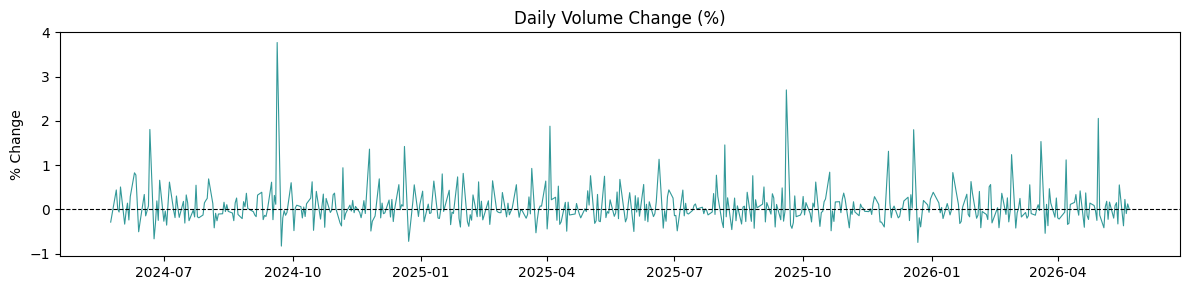

In [10]:
df['Volume_Change'] = df['Volume'].pct_change()

plt.figure(figsize=(12, 3))
plt.plot(df.index, df['Volume_Change'], color='teal', linewidth=0.8, alpha=0.8)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Daily Volume Change (%)')
plt.ylabel('% Change')
plt.tight_layout()
plt.show()



### The 8 Features Together

Let's look at all of them side by side to confirm they're all built correctly.

In [ ]:
feature_cols = [
    "Daily_Return",
    "MA5",
    "MA5_to_MA20",
    "Price_to_MA20",
    "Lag1_Return",
    "Lag2_Return",
    "Volatility_5d",
    "Volume_Change"
]

print("All 8 features — last 5 rows:")
print(df[feature_cols].dropna().tail().round(4))

print("Any missing values?")
print(df[feature_cols].isnull().sum())

All 8 features — last 5 rows:
            Daily_Return      MA5  MA5_to_MA20  Price_to_MA20  Lag1_Return  \
Date                                                                         
2026-05-18       -0.0080  297.990       1.0544         1.0539       0.0068   
2026-05-19        0.0038  298.824       1.0512         1.0517      -0.0080   
2026-05-20        0.0110  299.500       1.0482         1.0578       0.0038   
2026-05-21        0.0091  300.856       1.0471         1.0615       0.0110   
2026-05-22        0.0126  302.574       1.0462         1.0678       0.0091   

            Lag2_Return  Volatility_5d  Volume_Change  
Date                                                   
2026-05-18      -0.0022         0.0086        -0.3715  
2026-05-19       0.0068         0.0083         0.2251  
2026-05-20      -0.0080         0.0075        -0.0950  
2026-05-21       0.0038         0.0075         0.1239  
2026-05-22       0.0110         0.0083         0.0154  

Any missing values?
Daily_Retu



## 4 · Creating the Prediction Target Column

### What Is a Target?

In machine learning, the **target** (also called label or output) is what we want the model to predict.

Our target is simple:
- **1** = the stock price went **UP** the next day
- **0** = the stock price went **DOWN** (or stayed flat) the next day

Every row in our dataset represents one trading day. The target for that row answers: *"Will tomorrow be an up day?"*


### How to Create It

`shift(-1)` moves the Close column **up by one row**, so each row shows *tomorrow's* close.
We then compare: is tomorrow's close greater than today's close?

In [ ]:
# shift(-1) gives us tomorrow's closing price at today's row
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

print(df[['Close', 'Target']].tail(8))

                 Close  Target
Date                          
2026-05-13  298.869995       0
2026-05-14  298.209991       1
2026-05-15  300.230011       0
2026-05-18  297.839996       1
2026-05-19  298.970001       1
2026-05-20  302.250000       1
2026-05-21  304.989990       1
2026-05-22  308.820007       0


> ✅ Verify your logic: Find a row where tomorrow's Close is greater than today's Close. Does Target show 1? Find one where tomorrow's Close is lower. Does Target show 0?

### How Balanced Is the Target?

Before training any model, always check how your target is distributed. If 90% of days are "Up" and only 10% are "Down," the model can just guess "Up" every day and look 90% accurate — without learning anything.

Target
1    279
0    222
Name: count, dtype: int64


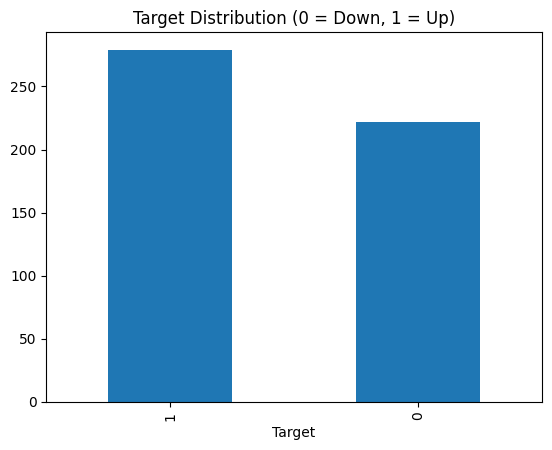

In [13]:
# Count how many Up days (1) and Down days (0) we have
print(df["Target"].value_counts())

# Visualize the distribution
df["Target"].value_counts().plot(
    kind="bar",
    title="Target Distribution (0 = Down, 1 = Up)"
)

plt.show()

> 💡 **What to expect:** Stock markets tend to go up slightly more often than they go down (historically ~53/47 for large cap stocks). A roughly balanced split like this is good news for our model.




## 5 · Data Leakage — The #1 Beginner Mistake

### What Is Data Leakage?

Data leakage means accidentally giving your model information that it **wouldn't have in the real world at prediction time**.

It's sneaky because your model will show amazing accuracy during training and testing — then completely fail in production. The model didn't learn anything real. It just memorized a cheat sheet.

### The Most Common Leakage Mistakes in Stock Projects

**Mistake 1: Keeping `Tomorrow_Return(created using shift(-1))` as a feature**

If you left it in, the model would literally see tomorrow's return and use it to predict tomorrow's direction. That's cheating — in the real world, you don't have tomorrow's return.

**Mistake 2: Using future moving averages**

A 20-day MA calculated on day 10 uses days 1–10 correctly. But if you're not careful about your rolling windows, you might accidentally include future data.

**Mistake 3: Normalizing across the entire dataset before splitting**

If you calculate mean/std on the full dataset (including test data) and then normalize, your training data "leaked" information about the future through the normalization. Always fit normalization on training data only — we'll handle this properly in Week 4.

**Mistake 4: Shuffling time series data**

Never shuffle rows in a time series dataset. If you shuffle, your "training" data will include dates from 2024 and your "test" data will include dates from 2022 — that's future-to-past leakage. Keep the data in time order. Always.

> ⚠️ **The golden rule:** At prediction time, for any given day, your model should only use information that was available at the end of that trading day — nothing from the future.



## 6 · Final Check and Saving the ML-Ready Dataset

### 6.1 — Remove NaN Rows

Features like rolling averages and lag returns create NaN rows at the start of the dataset. We need to drop these before saving — a model cannot handle NaN inputs.

In [15]:
# Remove rows that contain missing values
df_ml = df[feature_cols + ["Target"]].dropna()

print("Rows before:", len(df))
print("Rows after :", len(df_ml))

Rows before: 501
Rows after : 482


> 💡 **Why do we lose rows?** The largest window is MA20 (20 days) and Lag2 (2 days). So the first ~20 rows will have NaN values. Losing 20 rows from 500+ is fine.


### 6.2 — Final Dataset Check

In [16]:
print("Final dataset shape:", df_ml.shape)
print()
print("Feature columns and types:")
print(df_ml.dtypes)
print()
print("Summary stats:")
print(df_ml.describe().round(4))

Final dataset shape: (482, 9)

Feature columns and types:
Daily_Return     float64
MA5              float64
MA5_to_MA20      float64
Price_to_MA20    float64
Lag1_Return      float64
Lag2_Return      float64
Volatility_5d    float64
Volume_Change    float64
Target             int64
dtype: object

Summary stats:
       Daily_Return       MA5  MA5_to_MA20  Price_to_MA20  Lag1_Return  \
count      482.0000  482.0000     482.0000       482.0000     482.0000   
mean         0.0010  236.8737       1.0061         1.0078       0.0009   
std          0.0176   25.2174       0.0303         0.0389       0.0176   
min         -0.0925  185.3268       0.8873         0.8139      -0.0925   
25%         -0.0065  218.2642       0.9863         0.9825      -0.0065   
50%          0.0013  231.2813       1.0085         1.0103       0.0013   
75%          0.0090  256.9613       1.0286         1.0363       0.0089   
max          0.1533  302.5740       1.0686         1.0880       0.1533   

       Lag2_Return  



### 6.3 — Feature Correlation Check

Before saving, let's check if any features are highly correlated with each other. Highly correlated features give the model the same information twice — that's redundant and can hurt performance.

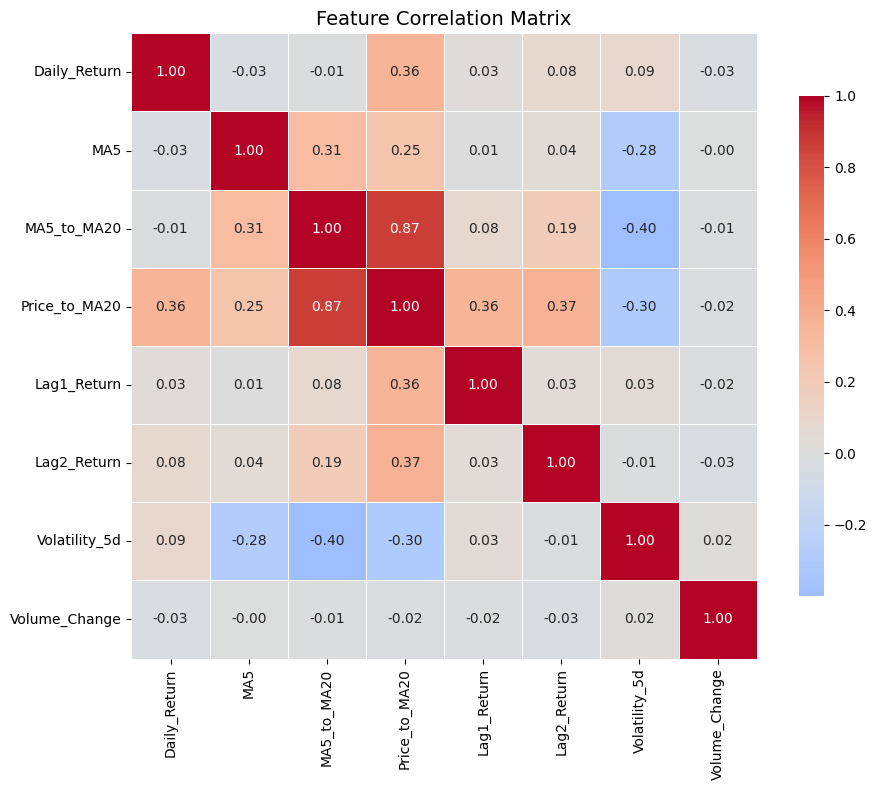

In [17]:
import seaborn as sns

corr = df_ml[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

> 🔍 **What to look for:**
> - Values close to **+1** or **-1** = highly correlated (redundant)
> - Values close to **0** = independent (good, the model gets new info from each)
> 
> You'll likely see `MA5_to_MA20` and `Price_to_MA20` somewhat correlated — that's acceptable since they capture related but not identical signals.



### 6.4 — Save the ML-Ready Dataset

In [18]:
os.makedirs("data/processed", exist_ok=True)
df_ml.to_csv("data/processed/AAPL_features.csv")

print(df_ml.tail())

            Daily_Return         MA5  MA5_to_MA20  Price_to_MA20  Lag1_Return  \
Date                                                                            
2026-05-18     -0.007961  297.989996     1.054430       1.053899     0.006774   
2026-05-19      0.003794  298.823999     1.051235       1.051748    -0.007961   
2026-05-20      0.010971  299.500000     1.048205       1.057830     0.003794   
2026-05-21      0.009065  300.856000     1.047122       1.061510     0.010971   
2026-05-22      0.012558  302.573999     1.046181       1.067777     0.009065   

            Lag2_Return  Volatility_5d  Volume_Change  Target  
Date                                                           
2026-05-18    -0.002208       0.008586      -0.371468       1  
2026-05-19     0.006774       0.008348       0.225056       1  
2026-05-20    -0.007961       0.007467      -0.095016       1  
2026-05-21     0.003794       0.007477       0.123864       1  
2026-05-22     0.010971       0.008312       0.0

### Your Dataset at a Glance

Here's a summary of what you've built:

| Item | Details |
| --- | --- |
| **File** | `data/processed/AAPL_features.csv` |
| **Rows** | ~480 trading days (after NaN removal) |
| **Features** | 8 columns |
| **Target** | `Target` — 1 = Up, 0 = Down |
| **Leakage** | None ✅ |
| **NaN values** | None ✅ |
| **Time order** | Preserved ✅ |

This file is ready to feed directly into a machine learning model next week.


## Week 3 Assignment

### Task 1 — Verify Your Feature File

Load your saved feature file and confirm:

```python
df = pd.read_csv(
    "data/processed/AAPL_features.csv",
    index_col="Date",
    parse_dates=True
)

print(df.shape)
print(df.isnull().sum().sum())
print(df["Target"].value_counts())
```

Check:
- No NaN values
- Target contains both 0 and 1
- Dataset loaded correctly

---
### Task 2 — Add 2 New Features

Create **at least 2 new features** that were not included in the notebook.

For each feature:
1. Write the code
2. Visualize it
3. Explain why it might help predict tomorrow's direction
---
### Task 3 — Try Another Stock

Run the entire feature engineering pipeline on another stock of your choice.

Examples:
- TSLA
- MSFT
- INFY.NS
- RELIANCE.NS

Save the result as:

```text
data/processed/<STOCK>_features.csv
```

Answer:
- Is the Target split similar to AAPL?
- Which stock appears more volatile?
- Which feature looks most different?

---



## Preview of Week 4

Next week we'll use the feature dataset we created to train our first machine learning model.

We'll learn how to:
- Split time-series data into train and test sets
- Train a model to predict stock direction
- Evaluate whether the model is actually learning useful patterns

---

## 📚 Resources for This Week

| Resource | Link |
| --- | --- |
| 🎥 Feature engineering explained simply | [youtube.com/watch?v=md0SjJKi5ys](https://www.youtube.com/watch?v=md0SjJKi5ys) |
| 📘 Pandas rolling & shift docs | [pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html) |
| 🎥 What is data leakage? — StatQuest | [youtube.com/watch?v=OFGaLUKuHhI](https://www.youtube.com/watch?v=OFGaLUKuHhI) |
| 📘 Seaborn heatmap docs | [seaborn.pydata.org/generated/seaborn.heatmap.html](https://seaborn.pydata.org/generated/seaborn.heatmap.html) |
| 📖 Feature engineering for time series — Towards Data Science | [towardsdatascience.com/feature-engineering-for-time-series](https://towardsdatascience.com/feature-engineering-for-time-series-d72c5459067d) |

---

🚀 **See you in Week 4**  
Next week: your first machine learning model. The dataset you built today is the foundation. You've got this.🚀